# Notebook for finding the parameters where recall is 1 and runtime is good

In [39]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: /cluster/home/eivindoy/masteroppgave


In [40]:
CITY = "rome"
MEASURE = "dtw"
DATA_SIZE = [2000]
SCHEME = "disk"
BUCKETING_METHOD = "original"

if BUCKETING_METHOD == "original":
    BUCKETING_METHOD_LABEL = "Strict" 
else:
    BUCKETING_METHOD_LABEL = "Loose"

## Read Bucketing Runtime CSV

In [41]:
folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name
runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head()

best_runtime_bucketing = float(runtime_bucketing["Total time (Seconds)"].min())
print(f"Best runtime bucketing: {best_runtime_bucketing} seconds")
runtime_bucketing.head(5)

Best runtime bucketing: 298.731 seconds


,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
City,,,,,,,,,
rome,dtw,0.6,25,30,2000,445.733,40.257,3.611,489.601
rome,dtw,0.6,25,40,2000,307.612,40.140,4.834,352.586
rome,dtw,0.6,35,30,2000,517.747,56.154,5.157,579.058
rome,dtw,0.6,35,40,2000,374.958,56.258,6.789,438.005
rome,dtw,0.6,45,30,2000,588.561,72.105,6.551,667.217


## Read No Bucketing Runtime CSV

In [42]:

folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"runtimes_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}_no_bucketing.csv"
file_path = folder_path + file_name
runtime_no_bucketing = pd.read_csv(file_path)
runtime_no_bucketing.head(5)

,City,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds)
0,rome,dtw,0.2,3,40,2000,9.453,5.058,14.511
1,rome,dtw,0.4,3,40,2000,17.861,5.121,22.982
2,rome,dtw,0.6,3,40,2000,24.559,5.246,29.805
3,rome,dtw,0.8,3,40,2000,30.214,5.388,35.602
4,rome,dtw,1.0,3,40,2000,36.239,4.986,41.225


## Read No Bucketing Correlation

In [43]:
DATA_SIZE_WITHOUT_BRACKETS = DATA_SIZE[0]
folder_path = f"../correlation/no_bucketing_correlation_values/"
file_name = f"correlation_results_{CITY}_disk_no_bucketing_{DATA_SIZE_WITHOUT_BRACKETS}.csv"
file_path = folder_path + file_name
correlation_no_bucketing = pd.read_csv(file_path, index_col=0)
correlation_no_bucketing.head(5)

#Merge runtime_no_bucketing and correlation_no_bucketing on columns "Diameter" and "Layers"
runtime_no_bucketing = pd.merge(runtime_no_bucketing, correlation_no_bucketing, on=["Diameter", "Layers"])
runtime_no_bucketing.head(10)


,City,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds),Correlation
0,rome,dtw,0.2,3,40,2000,9.453,5.058,14.511,0.177
1,rome,dtw,0.4,3,40,2000,17.861,5.121,22.982,0.305
2,rome,dtw,0.6,3,40,2000,24.559,5.246,29.805,0.404
3,rome,dtw,0.8,3,40,2000,30.214,5.388,35.602,0.456
4,rome,dtw,1.0,3,40,2000,36.239,4.986,41.225,0.497
5,rome,dtw,1.2,3,40,2000,42.219,5.417,47.636,0.518
6,rome,dtw,1.4,3,40,2000,50.325,5.492,55.817,0.537
7,rome,dtw,1.6,3,40,2000,58.638,5.594,64.232,0.541
8,rome,dtw,1.8,3,40,2000,66.077,5.787,71.864,0.537
9,rome,dtw,2.0,3,40,2000,78.798,5.859,84.657,0.551


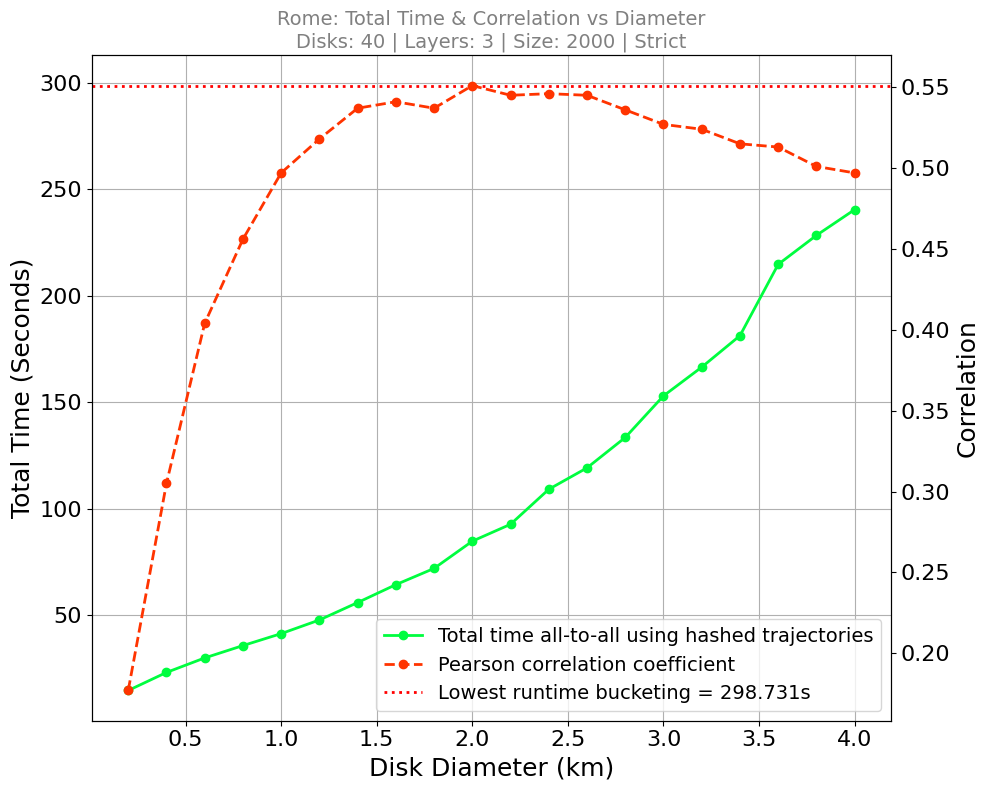

In [44]:
# Filter the runtime_no_bucketing dataframe to only include the rows where Layers = 3
filtered_runtime_no_bucketing = runtime_no_bucketing[runtime_no_bucketing["Layers"] == 3]

# print(filtered_runtime_no_bucketing[["Resolution", "Correlation"]])


import matplotlib.pyplot as plt
import numpy as np

def plot_total_time_vs_diameter(
    df,
    city: str,
    measure: str = "dtw",
    layers: int = 3,
    size: int = 500,
    lowest_runtime: float = None,  # Add this argument
):
    """
    Plots the relationship between diameter and total time (in seconds),
    and overlays correlation on a secondary y-axis with clear labels.
    Adds a horizontal line for the externally provided lowest total runtime.
    """

    # Filter the DataFrame
    filtered = df[
        (df['City'] == city) &
        (df['Measure'] == measure) &
        (df['Layers'] == layers) &
        (df['Size'] == size)
    ].sort_values(by='Diameter')

    # Extract values
    res = filtered['Diameter'].values
    total_time = filtered['Total time (Seconds)'].values
    corr = filtered['Correlation'].astype(float).values

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 8), dpi=100)
    ax2 = ax1.twinx()
    cmap = plt.get_cmap("gist_ncar")

    line1 = ax1.plot(res, total_time, color=cmap(0.3), marker='o', lw=2, label='Total time all-to-all using hashed trajectories')[0]
    line2 = ax2.plot(res, corr, color=cmap(0.7), marker='o', lw=2, linestyle='--', label='Pearson correlation coefficient')[0]

    # Use provided lowest_runtime if available
    if lowest_runtime is not None:
        line3 = ax1.axhline(
            y=lowest_runtime,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'Lowest runtime bucketing = {lowest_runtime:.3f}s'
        )
        lines = [line1, line2, line3]
    else:
        lines = [line1, line2]

    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="lower right", fontsize=14)

    # Axis labels and styling
    ax1.set_xlabel("Disk Diameter (km)", fontsize=18)
    ax1.set_ylabel("Total Time (Seconds)", fontsize=18)
    ax2.set_ylabel("Correlation", fontsize=18)
    

    ax1.tick_params(axis="both", which="major", labelsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=16)

    if city == "rome":
        disks = 40
    else:
        disks = 50

    ax1.set_title(
        f"{city.capitalize()}: Total Time & Correlation vs Diameter\nDisks: {disks} | Layers: {layers} | Size: {size} | {BUCKETING_METHOD_LABEL}",
        fontsize=14,
        color='grey'
    )

    ax1.grid(True)
    fig.tight_layout()
    plt.show()




plot_total_time_vs_diameter(
    filtered_runtime_no_bucketing,
    city=CITY,
    measure="dtw",
    layers=3,
    size=DATA_SIZE[0],
    lowest_runtime=best_runtime_bucketing  # Pass the value from your earlier cell
)


# filtered_runtime_no_bucketing.head(5)
